In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.legendre import leggauss

# This is my integration function
def gauss_quad(f,a,b,N,p):
    (xg,wg) = leggauss(p)
    h = (b-a)/N
    
    integ = 0.0
    for i in range(1,N+1):
        x_left = (i-1)*h + a
        xm = x_left + (xg+1)*h/2
        f_vals = f(xm)
        integ += h/2 * np.sum( f_vals*wg )
        
    return integ

def f1(x):
    return x**8

def f2(x):
    return np.abs(x - 1/np.sqrt(2))**3

def f3(x):
    return np.heaviside(x-1/np.sqrt(2),0)

def f4(x):
    return 1/np.sqrt(x)


# EXECUTE CODE BELOW

p = 5
Ns = [2**i for i in range(0,10)]
num = len(Ns)

integ_f1 = np.zeros((num,1))
integ_f2 = np.zeros((num,1))
integ_f3 = np.zeros((num,1))
integ_f4 = np.zeros((num,1))

for i in range(0,num):
    N = Ns[i]
    
    integ_f1[i] = gauss_quad(f1,-1,1,N,p)
    integ_f2[i] = gauss_quad(f2,-1,1,N,p)
    integ_f3[i] = gauss_quad(f3,-1,1,N,p)
    integ_f4[i] = gauss_quad(f4,0,1,N,p)

# Analytical solutions
f1_ref = 2/9
f2_ref = 17/8
f3_ref = 1 - 1/np.sqrt(2)
f4_ref = 2

# Compute relative error
errs_f1 = np.abs( f1_ref - integ_f1 ) / np.abs(f1_ref)
errs_f2 = np.abs( f2_ref - integ_f2 ) / np.abs(f2_ref)
errs_f3 = np.abs( f3_ref - integ_f3 ) / np.abs(f3_ref)
errs_f4 = np.abs( f4_ref - integ_f4 ) / np.abs(f4_ref)

h_abc = [2/n for n in Ns]
h_d = [1/n for n in Ns]

print('Done.')

Done.


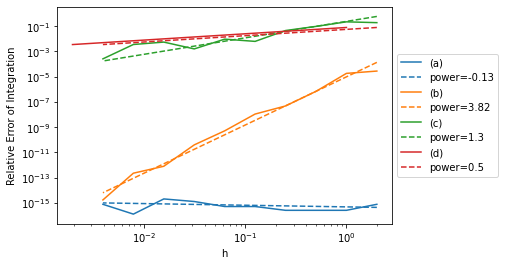

In [2]:
acolor = "tab:blue"
bcolor = "tab:orange"
ccolor = "tab:green"
dcolor = "tab:red"

from scipy.optimize import curve_fit

def model(x, A, B):
    return A * x**B

params_f1, _ = curve_fit(model, h_abc, errs_f1.ravel())
Af1, Bf1 = params_f1
params_f2, _ = curve_fit(model, h_abc[2:], errs_f2[2:].ravel())
Af2, Bf2 = params_f2
params_f3, _ = curve_fit(model, h_abc[2:], errs_f3[2:].ravel())
Af3, Bf3 = params_f3
params_f4, _ = curve_fit(model, h_d, errs_f4.ravel())
Af4, Bf4 = params_f4


fig,ax = plt.subplots()

plt.loglog(h_abc, errs_f1, label='(a)', color=acolor)
plt.loglog(h_abc, Af1*h_abc**Bf1, '--', label=f'power={np.round(Bf1,2)}', color=acolor)

plt.loglog(h_abc, errs_f2, label='(b)', color=bcolor)
plt.loglog(h_abc, Af2*h_abc**Bf2, '--', label=f'power={np.round(Bf2,2)}', color=bcolor)

plt.loglog(h_abc, errs_f3, label='(c)', color=ccolor)
plt.loglog(h_abc, Af3*h_abc**Bf3, '--', label=f'power={np.round(Bf3,2)}', color=ccolor)

plt.loglog(h_d, errs_f4, label='(d)', color=dcolor)
plt.loglog(h_abc, Af4*h_d**Bf4, '--', label=f'power={np.round(Bf4,2)}', color=dcolor)

ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xlabel('h')
plt.ylabel('Relative Error of Integration')

plt.show()